# Problema 1

### Regresie liniara -> Gradient descendent versiunea batch

Pasi in rezolvare:

- normalizarea datelor
- plot pt distributia datelor & plot pt “verificarea” liniaritatii (daca legatura intre y si x e una liniara)
- impartire date pe train si test
- invatare model (cu tool de GD sau cu cod propriu)
plot rezultate
- calcul metrici de performanta (eroarea)

### Pasul 1 -> verificari pt liniaritate si distributie

In [1]:
import math
import warnings; warnings.simplefilter('ignore')
import csv
import matplotlib.pyplot as plt
import os
import numpy as np

In [2]:
from sklearn.preprocessing import StandardScaler


# used for loading only the necessary data from the file
def loadData(fileName, inputVariabName, outputVariabName):
    data = []
    dataNames = []
    with open(fileName) as csv_file:
        csv_reader = csv.reader(csv_file, delimiter=',')
        line_count = 0
        for row in csv_reader:
            if line_count == 0:
                dataNames = row
            else:
                data.append(row)
            line_count += 1
    selectedVariable = dataNames.index(inputVariabName)
    inputs = [float(data[i][selectedVariable]) for i in range(len(data))]

    selectedOutput = dataNames.index(outputVariabName)
    outputs = [float(data[i][selectedOutput]) for i in range(len(data))]

    return inputs, outputs


# normalisation function
def normalisation(trainData, testData):
    scaler = StandardScaler()
    if not isinstance(trainData[0], list):
        #encode each sample into a list
        trainData = [[d] for d in trainData]
        testData = [[d] for d in testData]

        scaler.fit(trainData)  #  fit only on training data
        normalisedTrainData = scaler.transform(trainData) # apply same transformation to train data
        normalisedTestData = scaler.transform(testData)  # apply same transformation to test data

        #decode from list to raw values
        normalisedTrainData = [el[0] for el in normalisedTrainData]
        normalisedTestData = [el[0] for el in normalisedTestData]
    else:
        scaler.fit(trainData)  #  fit only on training data
        normalisedTrainData = scaler.transform(trainData) # apply same transformation to train data
        normalisedTestData = scaler.transform(testData)  # apply same transformation to test data
    return normalisedTrainData, normalisedTestData

# bulding the file path
crtDir =  os.getcwd()
filePath = os.path.join(crtDir, '', 'world-happiness-report-2017.csv')

# reading the required data from the file, using the defined function loadData
inputs, outputs = loadData(filePath, 'Economy..GDP.per.Capita.', 'Happiness.Score')
inputsFreedom, _ = loadData(filePath,'Freedom','Happiness.Score')

# combining the GDP & Freedom into one variable
inputsCombined = [[g, f] for g, f in zip(inputs, inputsFreedom)]

se visualizeaza datele extrase din fisier

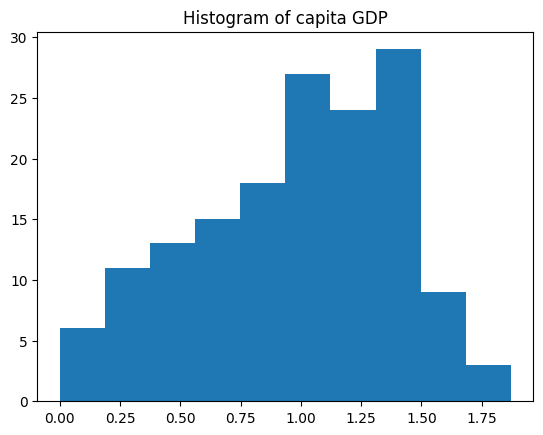

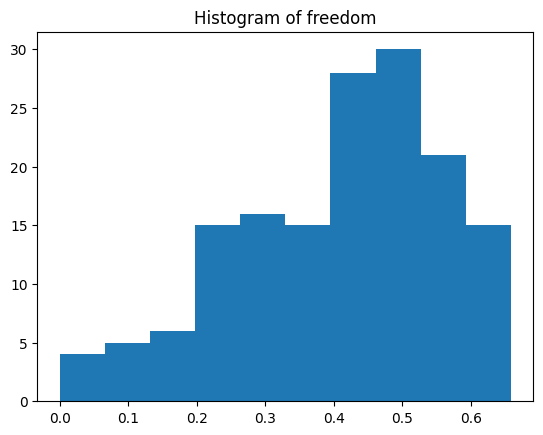

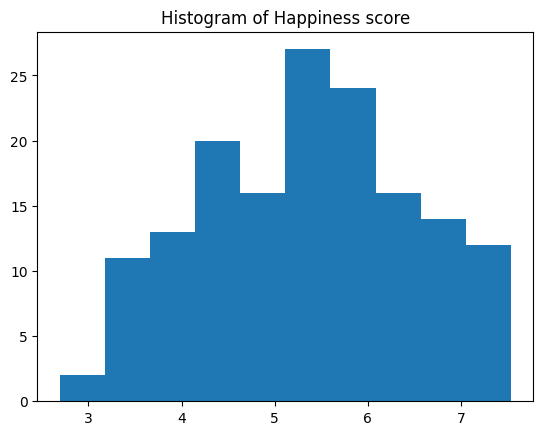

In [3]:
def plotDataHistogram(x, variableName):
    n, bins, patches = plt.hist(x, 10)
    plt.title('Histogram of ' + variableName)
    plt.show()

plotDataHistogram(inputs, "capita GDP")
plotDataHistogram(inputsFreedom,"freedom")
plotDataHistogram(outputs, "Happiness score")

se "verifica" liniaritatea datelor (inputs + outputs)

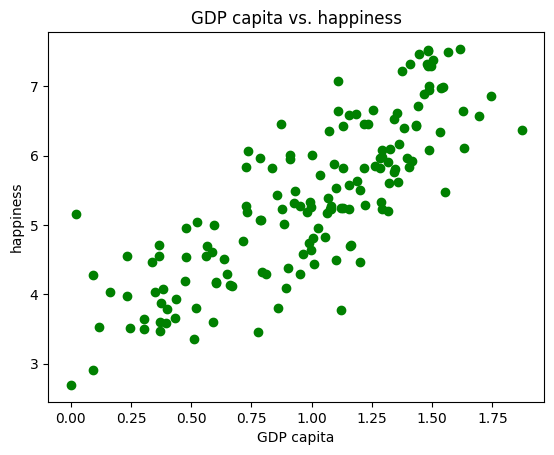

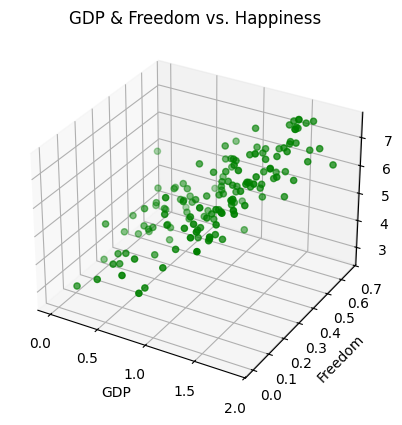

In [4]:
plt.plot(inputs, outputs, 'go')
plt.xlabel('GDP capita')
plt.ylabel('happiness')
plt.title('GDP capita vs. happiness')
plt.show()

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(inputs, inputsFreedom, outputs, c='g', marker='o')
ax.set_xlabel('GDP')
ax.set_ylabel('Freedom')
ax.set_zlabel('Happiness')
plt.title('GDP & Freedom vs. Happiness')
plt.show()

### Pasul 2 + 3 -> impartirea datelor pe train & test + standardizarea datelor

In [5]:
# making sure that the "random" numbers are always going to be the same ones (in order to get the same results every time)
np.random.seed(5)

# building an index vector & selecting 80% of it for training, and the rest 20% for testing the algorithm
indexes = [i for i in range(len(inputs))]
trainSample = np.random.choice(indexes, int(0.8 * len(inputs)), replace = False)
testSample = [i for i in indexes  if not i in trainSample]

# train & input for the first analysis -> GDP
trainInputs = [inputs[i] for i in trainSample]
trainOutputs = [outputs[i] for i in trainSample]

testInputs = [inputs[i] for i in testSample]
testOutputs = [outputs[i] for i in testSample]

trainInputs, testInputs = normalisation(trainInputs, testInputs)


# test & train for the second analysis -> GDP & Freedom
trainInputsCombined = [inputsCombined[i] for i in trainSample]
testInputsCombined = [inputsCombined[i] for i in testSample]

trainInputsCombined, testInputsCombined = normalisation(trainInputsCombined, testInputsCombined)

vizualizarea impartirii pentru ambele cazuri: GDP & GDP + Freedom

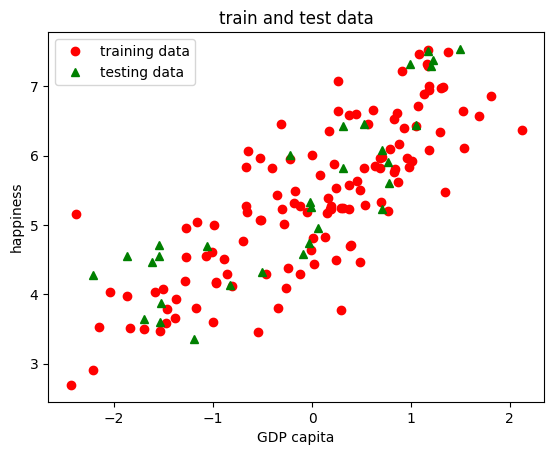

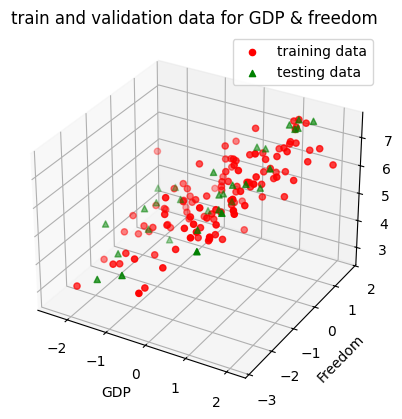

In [6]:

plt.plot(trainInputs, trainOutputs, 'ro', label = 'training data')   #train data are plotted by red and circle sign
plt.plot(testInputs, testOutputs, 'g^', label = 'testing data')     #test data are plotted by green and a triangle sign
plt.title('train and test data')
plt.xlabel('GDP capita')
plt.ylabel('happiness')
plt.legend()
plt.show()


trainGDP = [el[0] for el in trainInputsCombined]
trainFreedom = [el[1] for el in trainInputsCombined]

testGDP = [el[0] for el in testInputsCombined]
testFreedom = [el[1] for el in testInputsCombined]

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(trainGDP, trainFreedom, trainOutputs, c='r', marker='o', label='training data')
ax.scatter(testGDP, testFreedom, testOutputs, c='g', marker='^', label='testing data')
ax.set_xlabel('GDP')
ax.set_ylabel('Freedom')
ax.set_zlabel('Happiness')
plt.title('train and validation data for GDP & freedom')
plt.legend()
plt.show()

### Pasul 4 -> invatarea modelului + predictii

### CU TOOL

In [7]:
# the given data has to be a matrix
xx = [[el] for el in trainInputs]

from sklearn import linear_model



# FIRST ANALYSIS -> GDP

regressor = linear_model.SGDRegressor(alpha = 0.01, max_iter = 100)

# training the model
batch_size = 32
n_epochs = 10

for epoch in range(n_epochs):
    # se impart datele in batch-uri
    for i in range(0, len(xx), batch_size):
        xBatch = xx[i:i + batch_size]
        yBatch= trainOutputs[i:i + batch_size]

        # se antreneaza modelul pe batch-ul obtinut
        regressor.partial_fit(xBatch, yBatch)

w0, w1 = regressor.intercept_[0], regressor.coef_[0]
print('the learnt model for GDP: f(x) = ', w0, ' + ', w1, ' * x')




# SECOND ANALYSIS -> GDP & FREEDOM
regressorCombined = linear_model.SGDRegressor(alpha = 0.01, max_iter = 100)

for epoch in range(n_epochs):
    # se impart datele in batch-uri
    for i in range(0, len(trainInputsCombined), batch_size):
        xBatch = trainInputsCombined[i:i + batch_size]
        yBatch= trainOutputs[i:i + batch_size]

        # se antreneaza modelul pe batch-ul obtinut
        regressorCombined.partial_fit(xBatch, yBatch)

w0c, w1c, w2c = regressorCombined.intercept_[0], regressorCombined.coef_[0], regressorCombined.coef_[1]
print('the learnt model for GDP & Freedom: f(x) = ', w0c, ' + ', w1c, ' * x1 +', w2c,' * x2')

the learnt model for GDP: f(x) =  5.021426099923464  +  0.8189804119172477  * x
the learnt model for GDP & Freedom: f(x) =  5.021961452350473  +  0.7149693990847046  * x1 + 0.3542666249674686  * x2


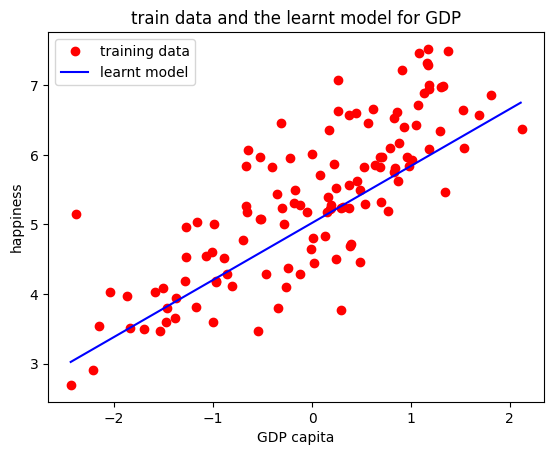

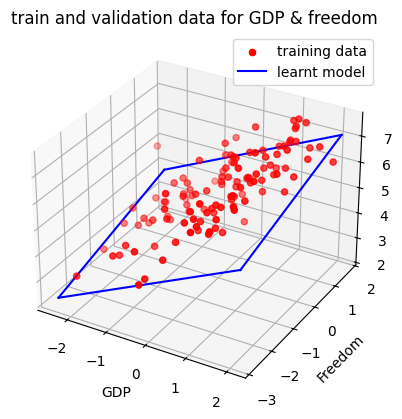

In [8]:
# visualizing

noOfPoints = 1000

# FIRST ANALYSIS -> GDP
xref = []
val = min(trainInputs)
step = (max(trainInputs) - min(trainInputs)) / noOfPoints
for i in range(1, noOfPoints):
    xref.append(val)
    val += step
yref = [w0 + w1 * el for el in xref]

plt.plot(trainInputs, trainOutputs, 'ro', label = 'training data')
plt.plot(xref, yref, 'b-', label = 'learnt model')
plt.title('train data and the learnt model for GDP')
plt.xlabel('GDP capita')
plt.ylabel('happiness')
plt.legend()
plt.show()


# SECOND ANALYSIS -> GDP & FREEDOM
# varfurile suprafetei
x_min, x_max = min(trainGDP), max(trainGDP)
y_min, y_max = min(trainFreedom), max(trainFreedom)

# se calculeaza si pe z
z_corner1 = w0c + w1c * x_min + w2c * y_min  # stanga-jos
z_corner2 = w0c + w1c * x_max + w2c * y_min  # dreapta-jos
z_corner3 = w0c + w1c * x_max + w2c * y_max  # dreapta-sus
z_corner4 = w0c + w1c * x_min + w2c * y_max  # stanga-sus

# deseneaza planul
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(trainGDP, trainFreedom, trainOutputs, c='r', marker='o', label = 'training data')
ax.set_xlabel('GDP')
ax.set_ylabel('Freedom')
ax.set_zlabel('Happiness')
plt.title('train and validation data for GDP & freedom')

ax.plot([x_min, x_max], [y_min, y_min], [z_corner1, z_corner2], color='blue', label='learnt model')
ax.plot([x_max, x_max], [y_min, y_max], [z_corner2, z_corner3], color='blue')
ax.plot([x_max, x_min], [y_max, y_max], [z_corner3, z_corner4], color='blue')
ax.plot([x_min, x_min], [y_max, y_min], [z_corner4, z_corner1], color='blue')

plt.legend()
plt.show()

Predictii

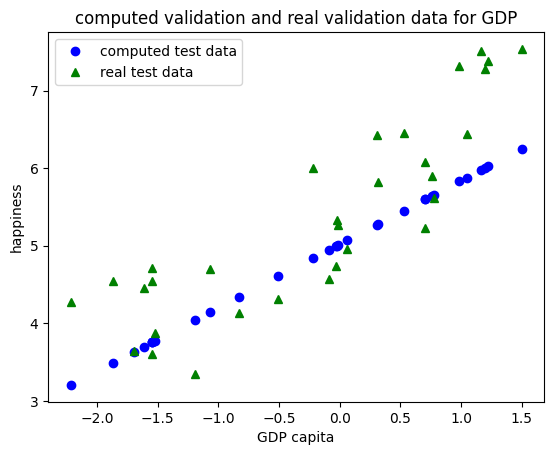

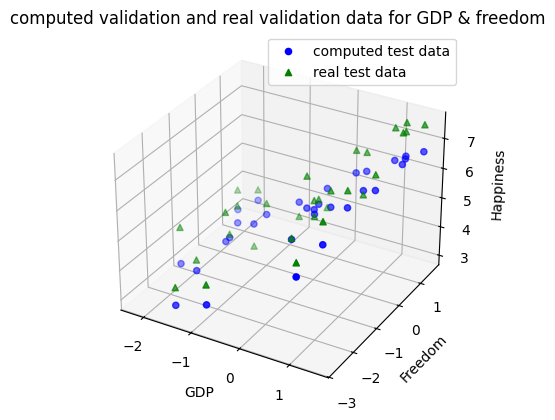

In [9]:
# GDP
computedOutputs = regressor.predict([[x] for x in testInputs])

# rezultatele obtinute de algoritmul antrenat VS rezultatele reale
plt.plot(testInputs, computedOutputs, 'bo', label = 'computed test data')
plt.plot(testInputs, testOutputs, 'g^', label = 'real test data')
plt.title('computed validation and real validation data for GDP')
plt.xlabel('GDP capita')
plt.ylabel('happiness')
plt.legend()
plt.show()



# GDP & Freedom
computedOutputsC = regressorCombined.predict([x for x in testInputsCombined])

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(testGDP, testFreedom, computedOutputsC, c='b', marker='o',label='computed test data')
ax.scatter(testGDP, testFreedom, testOutputs, c='g', marker='^',label='real test data')
ax.set_xlabel('GDP')
ax.set_ylabel('Freedom')
ax.set_zlabel('Happiness')
plt.title('computed validation and real validation data for GDP & freedom')
plt.legend()
plt.show()

### FOLOSIND COD PROPRIU

In [10]:
# the given data has to be a matrix
xx = [[el] for el in trainInputs]

import MyRegression


# FIRST ANALYSIS -> GDP

regressorP = MyRegression.MyRegression()

# training the model
batch_size = 32
n_epochs = 10

regressorP.fit(xx, trainOutputs)
w0p, w1p = regressorP.intercept_, regressorP.coef_[0]
print('the learnt model for GDP: f(x) = ', w0p, ' + ', w1p, ' * x')




# SECOND ANALYSIS -> GDP & FREEDOM
regressorCombinedP = MyRegression.MyRegression()
regressorCombinedP.fit(trainInputsCombined, trainOutputs)

w0cp, w1cp, w2cp = regressorCombinedP.intercept_, regressorCombinedP.coef_[0], regressorCombinedP.coef_[1]
print('the learnt model for GDP & Freedom: f(x) = ', w0cp, ' + ', w1cp, ' * x1 +', w2cp,' * x2')

the learnt model for GDP: f(x) =  5.276619829583303  +  0.8724444222689639  * x
the learnt model for GDP & Freedom: f(x) =  5.258853686985361  +  0.7875962432399136  * x1 + 0.3181361560211771  * x2


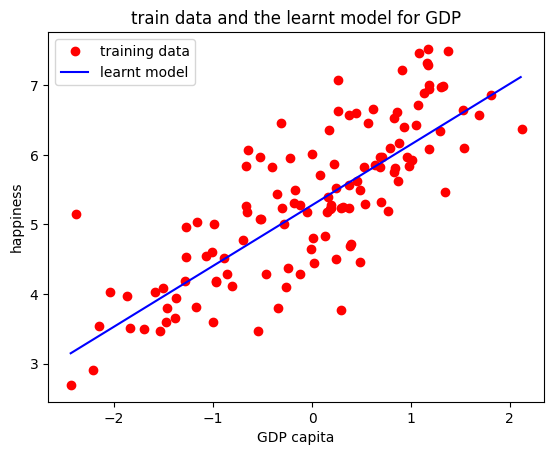

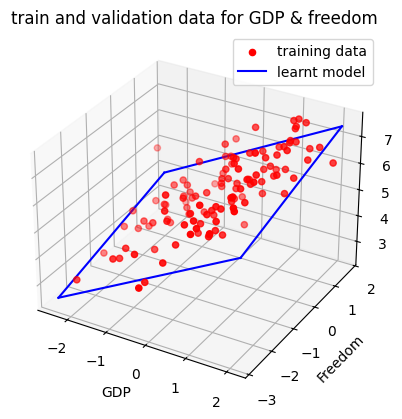

In [11]:
# visualizing

noOfPoints = 1000

# FIRST ANALYSIS -> GDP
xref = []
val = min(trainInputs)
step = (max(trainInputs) - min(trainInputs)) / noOfPoints
for i in range(1, noOfPoints):
    xref.append(val)
    val += step
yref = [w0p + w1p * el for el in xref]

plt.plot(trainInputs, trainOutputs, 'ro', label = 'training data')
plt.plot(xref, yref, 'b-', label = 'learnt model')
plt.title('train data and the learnt model for GDP')
plt.xlabel('GDP capita')
plt.ylabel('happiness')
plt.legend()
plt.show()


# SECOND ANALYSIS -> GDP & FREEDOM
# varfurile suprafetei
x_min, x_max = min(trainGDP), max(trainGDP)
y_min, y_max = min(trainFreedom), max(trainFreedom)

# se calculeaza si pe z
z_corner1 = w0cp + w1cp * x_min + w2cp * y_min  # stanga-jos
z_corner2 = w0cp + w1cp * x_max + w2cp * y_min  # dreapta-jos
z_corner3 = w0cp + w1cp * x_max + w2cp * y_max  # dreapta-sus
z_corner4 = w0cp + w1cp * x_min + w2cp * y_max  # stanga-sus

# deseneaza planul
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(trainGDP, trainFreedom, trainOutputs, c='r', marker='o', label = 'training data')
ax.set_xlabel('GDP')
ax.set_ylabel('Freedom')
ax.set_zlabel('Happiness')
plt.title('train and validation data for GDP & freedom')

ax.plot([x_min, x_max], [y_min, y_min], [z_corner1, z_corner2], color='blue', label='learnt model')
ax.plot([x_max, x_max], [y_min, y_max], [z_corner2, z_corner3], color='blue')
ax.plot([x_max, x_min], [y_max, y_max], [z_corner3, z_corner4], color='blue')
ax.plot([x_min, x_min], [y_max, y_min], [z_corner4, z_corner1], color='blue')

plt.legend()
plt.show()

Predictii

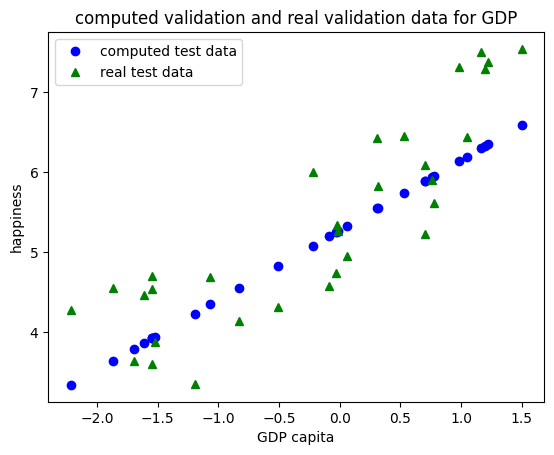

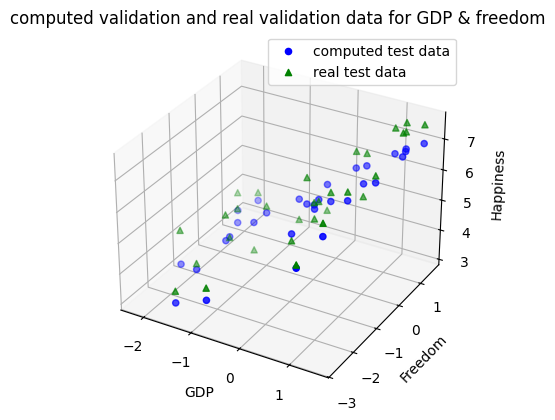

In [12]:
# GDP
computedOutputsP = regressorP.predict([[x] for x in testInputs])

# rezultatele obtinute de algoritmul antrenat VS rezultatele reale
plt.plot(testInputs, computedOutputsP, 'bo', label = 'computed test data')
plt.plot(testInputs, testOutputs, 'g^', label = 'real test data')
plt.title('computed validation and real validation data for GDP')
plt.xlabel('GDP capita')
plt.ylabel('happiness')
plt.legend()
plt.show()



# GDP & Freedom
computedOutputsCP = regressorCombinedP.predict([x for x in testInputsCombined])

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(testGDP, testFreedom, computedOutputsCP, c='b', marker='o',label='computed test data')
ax.scatter(testGDP, testFreedom, testOutputs, c='g', marker='^',label='real test data')
ax.set_xlabel('GDP')
ax.set_ylabel('Freedom')
ax.set_zlabel('Happiness')
plt.title('computed validation and real validation data for GDP & freedom')
plt.legend()
plt.show()

### Pasul 5 -> metrici de performanta

CU TOOL

In [13]:
import math

def error_rmse(y_predicted, y_true):
    error = 0.0
    for t1,t2 in zip(y_predicted, y_true):
        error += (t1 - t2)**2
    error = error / len(y_true)
    return math.sqrt(error)

def error_mae(y_predicted, y_true):
    error = 0.0
    for t1,t2 in zip(y_predicted, y_true):
        error += abs(t1 - t2)
    error = error / len(y_true)
    return error

print("GDP Performance")
error1 = error_rmse(computedOutputs, testOutputs)
error2 = error_mae(computedOutputs, testOutputs)
print('prediction mean square error: ', error1)
print('prediction error using the mean absolute value: ', error2)

print("\nGDP & Freedom Performance")
error1 = error_rmse(computedOutputsC, testOutputs)
error2 = error_mae(computedOutputsC, testOutputs)
print('prediction mean square error: ', error1)
print('prediction error using the mean absolute value: ', error2)

GDP Performance
prediction mean square error:  0.805140585672757
prediction error using the mean absolute value:  0.6605758650432331

GDP & Freedom Performance
prediction mean square error:  0.6984235510469147
prediction error using the mean absolute value:  0.6173462298461803


FOLOSIND COD PROPRIU

In [14]:
print("GDP Performance")
error1 = error_rmse(computedOutputsP, testOutputs)
error2 = error_mae(computedOutputsP, testOutputs)
print('prediction mean square error: ', error1)
print('prediction error using the mean absolute value: ', error2)

print("\nGDP & Freedom Performance")
error1 = error_rmse(computedOutputsCP, testOutputs)
error2 = error_mae(computedOutputsCP, testOutputs)
print('prediction mean square error: ', error1)
print('prediction error using the mean absolute value: ', error2)

GDP Performance
prediction mean square error:  0.6699584384949023
prediction error using the mean absolute value:  0.5725481637500188

GDP & Freedom Performance
prediction mean square error:  0.5648763539790357
prediction error using the mean absolute value:  0.48334572411560833
